# Diabetes Risk Prediction — Complete Pipeline

**Dataset:** Diabetes Health Indicators (~253k rows, 22 columns)  
**Goal:** EDA → Cleaning → Feature Engineering → Model Training & Comparison

---
## Pipeline Sections
1. Setup & Imports
2. EDA — shape, types, distributions, correlations
3. Data Cleaning — nulls, duplicates, outliers
4. Feature Engineering
5. Model Training — Logistic Regression, Decision Tree, Random Forest, XGBoost
6. Results Comparison

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import mlflow
import mlflow.sklearn

pd.set_option('display.max_columns', None)

In [2]:
# Load raw dataset
df_diabetes = pd.read_csv('../data/diabetes.csv')
print(f'Raw dataset shape: {df_diabetes.shape}')

Raw dataset shape: (253680, 22)


---
## 2. EDA

In [3]:
print('Shape:', df_diabetes.shape, '\n')

df_diabetes.info()

Shape: (253680, 22) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 n

In [ ]:
# Summary statistics
df_diabetes.describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


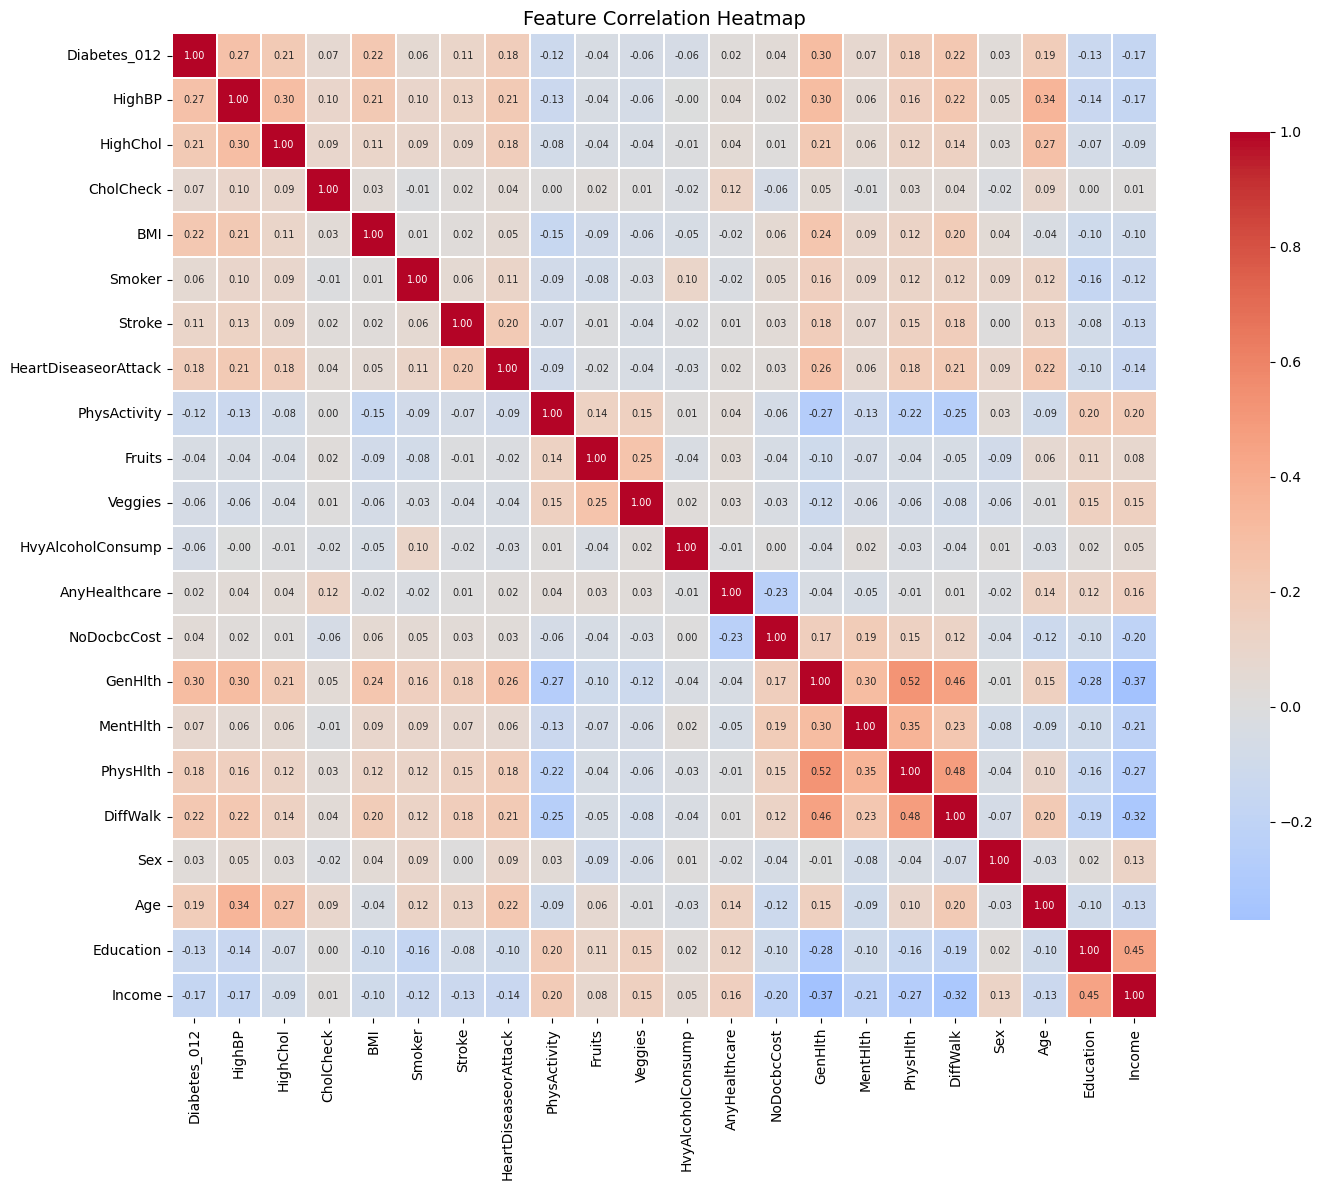

In [5]:
# Correlation heatmap (with correlation values)
corr = df_diabetes.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8}
 )
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Class distribution
target_counts = df_diabetes["Diabetes_012"].value_counts().sort_index()
target_pct = (target_counts / len(df_diabetes) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})
target_summary

,count,percentage
Diabetes_012,,
0.0,213703,84.24
1.0,4631,1.83
2.0,35346,13.93


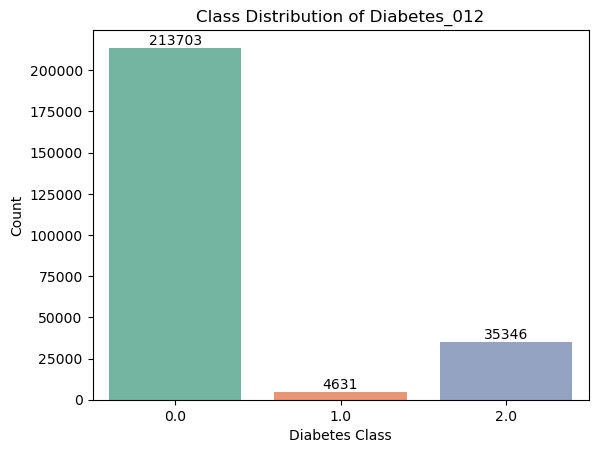

In [7]:
ax = sns.countplot(
    data=df_diabetes,
    x="Diabetes_012",
    hue="Diabetes_012",
    palette="Set2",
    legend=False
)
ax.set_title("Class Distribution of Diabetes_012")
ax.set_xlabel("Diabetes Class")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

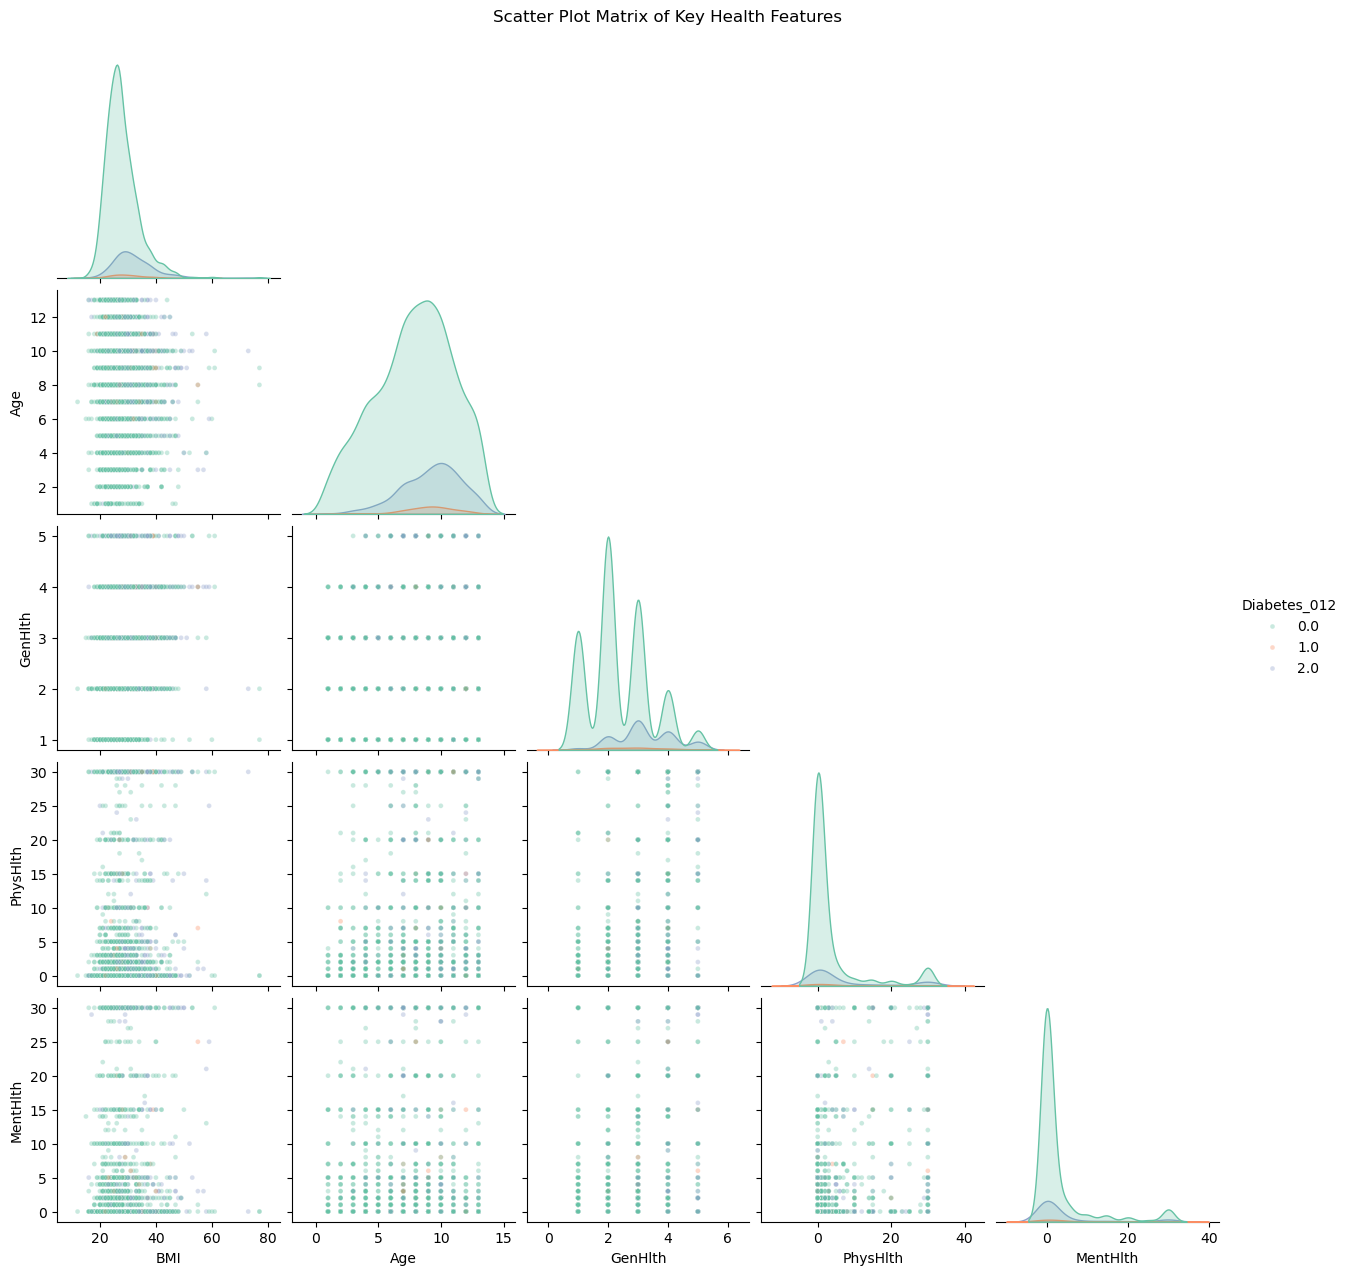

In [8]:
# Scatter plot matrix (pairplot)
pairplot_cols = ['BMI', 'Age', 'GenHlth', 'PhysHlth', 'MentHlth', 'Diabetes_012']

# Sample rows for faster rendering while preserving class proportions
df_pair = df_diabetes[pairplot_cols].sample(n=3000, random_state=42)

sns.pairplot(
    data=df_pair,
    vars=['BMI', 'Age', 'GenHlth', 'PhysHlth', 'MentHlth'],
    hue='Diabetes_012',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.35, 's': 12},
    diag_kws={'fill': True},
    palette='Set2'
 )
plt.suptitle('Scatter Plot Matrix of Key Health Features', y=1.02)
plt.show()

---
## 3. Data Cleaning

In [9]:
# Missing values
print('Missing values per column:', df_diabetes.isnull().sum())

Missing values per column: Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [10]:
# Duplicates
n_dupes = df_diabetes.duplicated().sum()
print(f'Duplicate rows: {n_dupes:,}  ({n_dupes/len(df_diabetes)*100:.2f}%)')

# Drop duplicates — same person answering twice adds no information
df_clean = df_diabetes.drop_duplicates().reset_index(drop=True)
print(f'Shape after removing duplicates: {df_clean.shape}')

Duplicate rows: 23,899  (9.42%)
Shape after removing duplicates: (229781, 22)


---
## 4. Feature Engineering

Most features are already binary or ordinal — minimal encoding needed.  
We'll add three meaningful derived features.

In [11]:
# BMI category
def bmi_category(bmi):
    if bmi < 18.5: return 0   # Underweight
    if bmi < 25:   return 1   # Normal
    if bmi < 30:   return 2   # Overweight
    return 3                  # Obese

df_clean['BMI_cat'] = df_clean['BMI'].apply(bmi_category)
print('BMI category distribution:')
print(df_clean['BMI_cat'].value_counts().sort_index().rename({0:'Underweight',1:'Normal',2:'Overweight',3:'Obese'}))

BMI category distribution:
BMI_cat
Underweight     3053
Normal         58927
Overweight     82859
Obese          84942
Name: count, dtype: int64


In [12]:
# Create binary target column
df_clean['Diabetes_Binary'] = (df_clean['Diabetes_012'] > 0).astype(int)
df_clean = df_clean.drop(columns=['Diabetes_012'])

print('Final dataset shape:', df_clean.shape)
print('Target balance:')
print(df_clean['Diabetes_Binary'].value_counts(normalize=True).round(3))
df_clean.head()

Final dataset shape: (229781, 23)
Target balance:
Diabetes_Binary
0    0.827
1    0.173
Name: proportion, dtype: float64


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_cat,Diabetes_Binary
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,3,0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,2,0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,2,0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,2,0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,1,0


---
## 5. Model Training & Comparison

In [13]:
# Prepare data for modeling
X = df_clean.drop(columns=['Diabetes_Binary'])  # features
y = df_clean['Diabetes_Binary']   # target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12, stratify=y
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 183824
Test set size: 45957


In [14]:
# Model hyperparameters 

lr_params = {
    "model_type":    "logistic_regression",
    "C":             1.0,        # inverse regularisation strength
    "max_iter":      1000,
    "class_weight":  "balanced", # compensates for imbalance
    "random_state":  12,
}

dt_params = {
    "model_type": "decision_tree",
    "max_depth": 8,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "class_weight": "balanced",
    "random_state": 12
}

rf_params = {
    "model_type": "random_forest",
    "n_estimators": 300,
    "max_depth": 12,
    "min_samples_split": 20,
    "min_samples_leaf": 8,
    "class_weight": "balanced_subsample",
    "random_state": 12
}

xgb_params = {
    "model_type": "xgboost",
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 5,
    "random_state": 12
}

In [15]:
# MLflow experiment

mlflow.set_experiment("diabetes-risk")

2026/04/24 19:01:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/24 19:01:11 INFO mlflow.store.db.utils: Updating database tables
2026/04/24 19:01:11 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/24 19:01:11 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/04/24 19:01:11 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/04/24 19:01:11 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/04/24 19:01:11 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026/04/24 19:01:11 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2026/04/24 19:01:11 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2026/04/24 19:01:11 INFO alembic.runtime.migration: Running 

<Experiment: artifact_location='/Users/kumar/Desktop/Projects.nosync/Personal/diabetes_risk_prediction/notebooks/mlruns/1', creation_time=1777050072003, experiment_id='1', last_update_time=1777050072003, lifecycle_stage='active', name='diabetes-risk', tags={}>

In [16]:
# Logistic Regression
with mlflow.start_run(run_name='logistic_regression'):

    model_lr = LogisticRegression(
        C=lr_params["C"],
        max_iter=lr_params["max_iter"],
        class_weight=lr_params["class_weight"],
        random_state=lr_params["random_state"],
    )
    model_lr.fit(X_train, y_train)

    y_pred_lr = model_lr.predict(X_test)
    y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

    lr_metrics = {
        "accuracy": accuracy_score(y_test, y_pred_lr),
        "f1":       f1_score(y_test, y_pred_lr),
        "roc_auc":  roc_auc_score(y_test, y_proba_lr),
    }

    mlflow.log_params(lr_params)
    mlflow.log_metrics(lr_metrics)
    mlflow.sklearn.log_model(model_lr, "model")

print("Logistic Regression")
print(f"  Accuracy : {lr_metrics['accuracy']:.4f}")
print(f"  F1 Score : {lr_metrics['f1']:.4f}")
print(f"  ROC AUC  : {lr_metrics['roc_auc']:.4f}")

2026/04/24 19:01:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logistic Regression
  Accuracy : 0.7145
  F1 Score : 0.4766
  ROC AUC  : 0.8026


In [17]:
# Decision Tree
with mlflow.start_run(run_name="decision_tree"):
    model_dt = DecisionTreeClassifier(
        max_depth=dt_params["max_depth"],
        min_samples_split=dt_params["min_samples_split"],
        min_samples_leaf=dt_params["min_samples_leaf"],
        class_weight=dt_params["class_weight"],
        random_state=dt_params["random_state"]
    )
    model_dt.fit(X_train, y_train)

    y_pred_dt = model_dt.predict(X_test)
    y_proba_dt = model_dt.predict_proba(X_test)[:, 1]

    dt_metrics = {
        "accuracy": accuracy_score(y_test, y_pred_dt),
        "f1": f1_score(y_test, y_pred_dt),
        "roc_auc": roc_auc_score(y_test, y_proba_dt),
    }

    mlflow.log_params(dt_params)
    mlflow.log_metrics(dt_metrics)
    mlflow.sklearn.log_model(model_dt, "model")

print("Decision Tree")
print(f"  Accuracy : {dt_metrics['accuracy']:.4f}")
print(f"  F1 Score : {dt_metrics['f1']:.4f}")
print(f"  ROC AUC  : {dt_metrics['roc_auc']:.4f}")

2026/04/24 19:01:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Decision Tree
  Accuracy : 0.6995
  F1 Score : 0.4655
  ROC AUC  : 0.7965


In [18]:
# Random Forest
with mlflow.start_run(run_name="random_forest"):
    model_rf = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_split=rf_params["min_samples_split"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        class_weight=rf_params["class_weight"],
        random_state=rf_params["random_state"],
        n_jobs=-1
    )
    model_rf.fit(X_train, y_train)

    y_pred_rf = model_rf.predict(X_test)
    y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

    rf_metrics = {
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "f1": f1_score(y_test, y_pred_rf),
        "roc_auc": roc_auc_score(y_test, y_proba_rf),
    }

    mlflow.log_params(rf_params)
    mlflow.log_metrics(rf_metrics)
    mlflow.sklearn.log_model(model_rf, "model")

print("Random Forest")
print(f"  Accuracy : {rf_metrics['accuracy']:.4f}")
print(f"  F1 Score : {rf_metrics['f1']:.4f}")
print(f"  ROC AUC  : {rf_metrics['roc_auc']:.4f}")

2026/04/24 19:01:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest
  Accuracy : 0.7250
  F1 Score : 0.4811
  ROC AUC  : 0.8063


In [19]:
# XGBoost
with mlflow.start_run(run_name="xgboost"):
    model_xgb = XGBClassifier(
        n_estimators=xgb_params["n_estimators"],
        max_depth=xgb_params["max_depth"],
        learning_rate=xgb_params["learning_rate"],
        subsample=xgb_params["subsample"],
        colsample_bytree=xgb_params["colsample_bytree"],
        scale_pos_weight=xgb_params["scale_pos_weight"],
        random_state=xgb_params["random_state"],
        eval_metric="logloss"
    )
    model_xgb.fit(X_train, y_train)

    y_pred_xgb = model_xgb.predict(X_test)
    y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

    xgb_metrics = {
        "accuracy": accuracy_score(y_test, y_pred_xgb),
        "f1": f1_score(y_test, y_pred_xgb),
        "roc_auc": roc_auc_score(y_test, y_proba_xgb),
    }

    mlflow.log_params(xgb_params)
    mlflow.log_metrics(xgb_metrics)
    mlflow.sklearn.log_model(model_xgb, "model")

print("XGBoost")
print(f"  Accuracy : {xgb_metrics['accuracy']:.4f}")
print(f"  F1 Score : {xgb_metrics['f1']:.4f}")
print(f"  ROC AUC  : {xgb_metrics['roc_auc']:.4f}")

2026/04/24 19:01:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost
  Accuracy : 0.7072
  F1 Score : 0.4742
  ROC AUC  : 0.8056


---
## 6. Results Comparison

In [20]:
# Create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_metrics['accuracy'], dt_metrics['accuracy'], rf_metrics['accuracy'], xgb_metrics['accuracy']],
    'F1 Score': [lr_metrics['f1'], dt_metrics['f1'], rf_metrics['f1'], xgb_metrics['f1']],
    'ROC AUC': [lr_metrics['roc_auc'], dt_metrics['roc_auc'], rf_metrics['roc_auc'], xgb_metrics['roc_auc']]
})

results_sorted = results.sort_values('ROC AUC', ascending=False).reset_index(drop=True)
print('\n=== Model Comparison (sorted by ROC AUC) ===')
print(results_sorted.to_string(index=False))

print(f'\nBest model: {results_sorted.iloc[0]["Model"]} (ROC AUC: {results_sorted.iloc[0]["ROC AUC"]:.4f})')


=== Model Comparison (sorted by ROC AUC) ===
              Model  Accuracy  F1 Score  ROC AUC
      Random Forest  0.725047  0.481110 0.806305
            XGBoost  0.707205  0.474211 0.805599
Logistic Regression  0.714494  0.476605 0.802627
      Decision Tree  0.699458  0.465480 0.796503

Best model: Random Forest (ROC AUC: 0.8063)
